In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os



In [28]:
df=pd.read_csv("C:\\Users\\Reetesh\\Desktop\\Timeseries Forecasting project\\store_sales.csv")
df.head()

,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0


## ***1: EDA***

In [29]:
print(df.info())
print("-"*80)
print(df.describe())
print("-"*80)
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   str    
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 285.3 KB
None
--------------------------------------------------------------------------------
             store        sales        promo      holiday
count  7300.000000  7300.000000  7300.000000  7300.000000
mean      5.500000   228.434571     0.202192     0.104110
std       2.872478    26.625636     0.401662     0.305424
min       1.000000   160.710000     0.000000     0.000000
25%       3.000000   209.217500     0.000000     0.000000
50%       5.500000   226.795000     0.000000     0.000000
75%       8.000000   245.590000     0.000000     0.000000
max      10.000000   340.7300

In [30]:
print(df.info()) #check date format again


<class 'pandas.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   str    
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 285.3 KB
None


In [31]:
print(df.nunique())
print("-"*80)
print(df.duplicated().sum())

date        730
store        10
sales      5162
promo         2
holiday       2
dtype: int64
--------------------------------------------------------------------------------
0


In [32]:
#We convert it into datetime because later we'll extract year,month,weekday,week,quarter
df['date_time']=pd.to_datetime(df['date'])

#we sort the time series to create correct lag features in future
df=df.sort_values(['date_time', 'store'])
print(df.head())



            date  store   sales  promo  holiday  date_time
0     2022-01-01      1  184.78      0        0 2022-01-01
730   2022-01-01      2  167.91      0        0 2022-01-01
1460  2022-01-01      3  217.27      0        1 2022-01-01
2190  2022-01-01      4  177.10      0        0 2022-01-01
2920  2022-01-01      5  171.59      0        0 2022-01-01


In [33]:
df.set_index('date_time', inplace=True)  #--Optional
print(df.head())

                  date  store   sales  promo  holiday
date_time                                            
2022-01-01  2022-01-01      1  184.78      0        0
2022-01-01  2022-01-01      2  167.91      0        0
2022-01-01  2022-01-01      3  217.27      0        1
2022-01-01  2022-01-01      4  177.10      0        0
2022-01-01  2022-01-01      5  171.59      0        0


In [34]:
print(df.groupby('store')['sales'].sum())
print("-"*80)
print(df.groupby('promo')['sales'].sum())
print("-"*80)
print(df.groupby('holiday')['sales'].sum())

store
1     169912.36
2     159293.35
3     159553.75
4     173784.73
5     161479.82
6     172590.88
7     169942.26
8     163896.68
9     178600.69
10    158517.85
Name: sales, dtype: float64
--------------------------------------------------------------------------------
promo
0    1295659.90
1     371912.47
Name: sales, dtype: float64
--------------------------------------------------------------------------------
holiday
0    1467298.30
1     200274.07
Name: sales, dtype: float64


In [35]:
#check date range
print("start:",df.index.min(), "|  end:",df.index.max())

print("-"*80)

#check date missing
date_range=pd.date_range(df.index.min(), df.index.max())
#print(date_range)

missing=date_range.difference(df.index)
print(pd.DataFrame(missing))



start: 2022-01-01 00:00:00 |  end: 2023-12-31 00:00:00
--------------------------------------------------------------------------------
Empty DataFrame
Columns: [0]
Index: []


In [36]:
df.index.nunique()

730

*DOUBT: what to do if any date row is missing????*


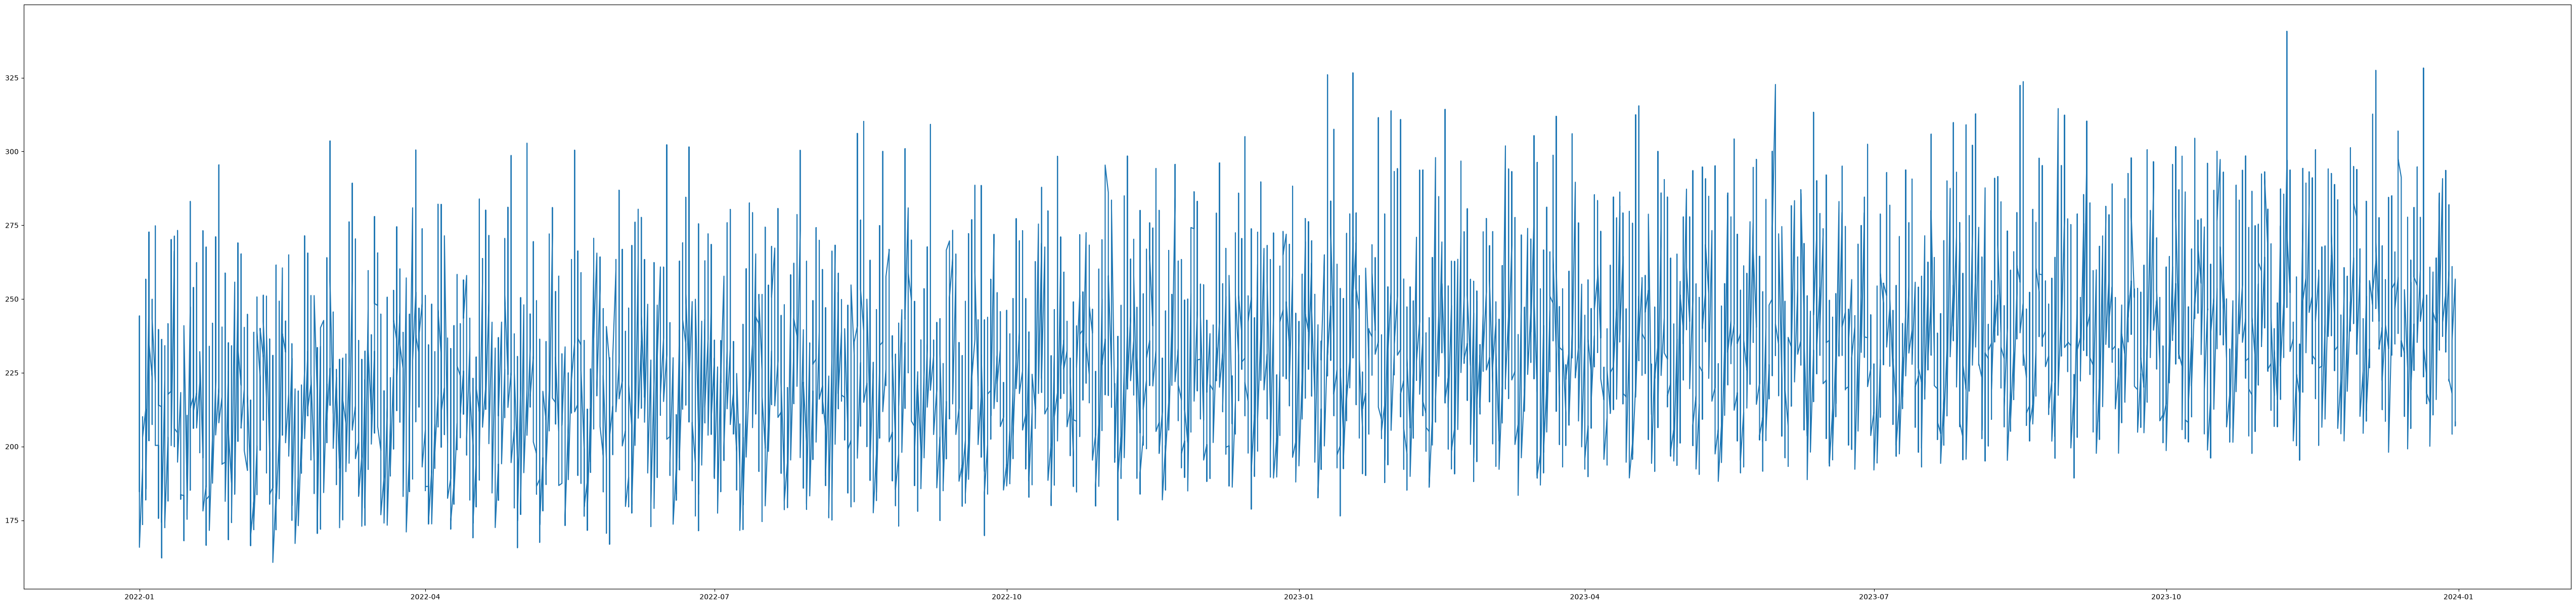

In [ ]:
#Visualize the Trend line chart
plt.figure(figsize=(65,15))

plt.plot(df['sales'] )
plt.show()

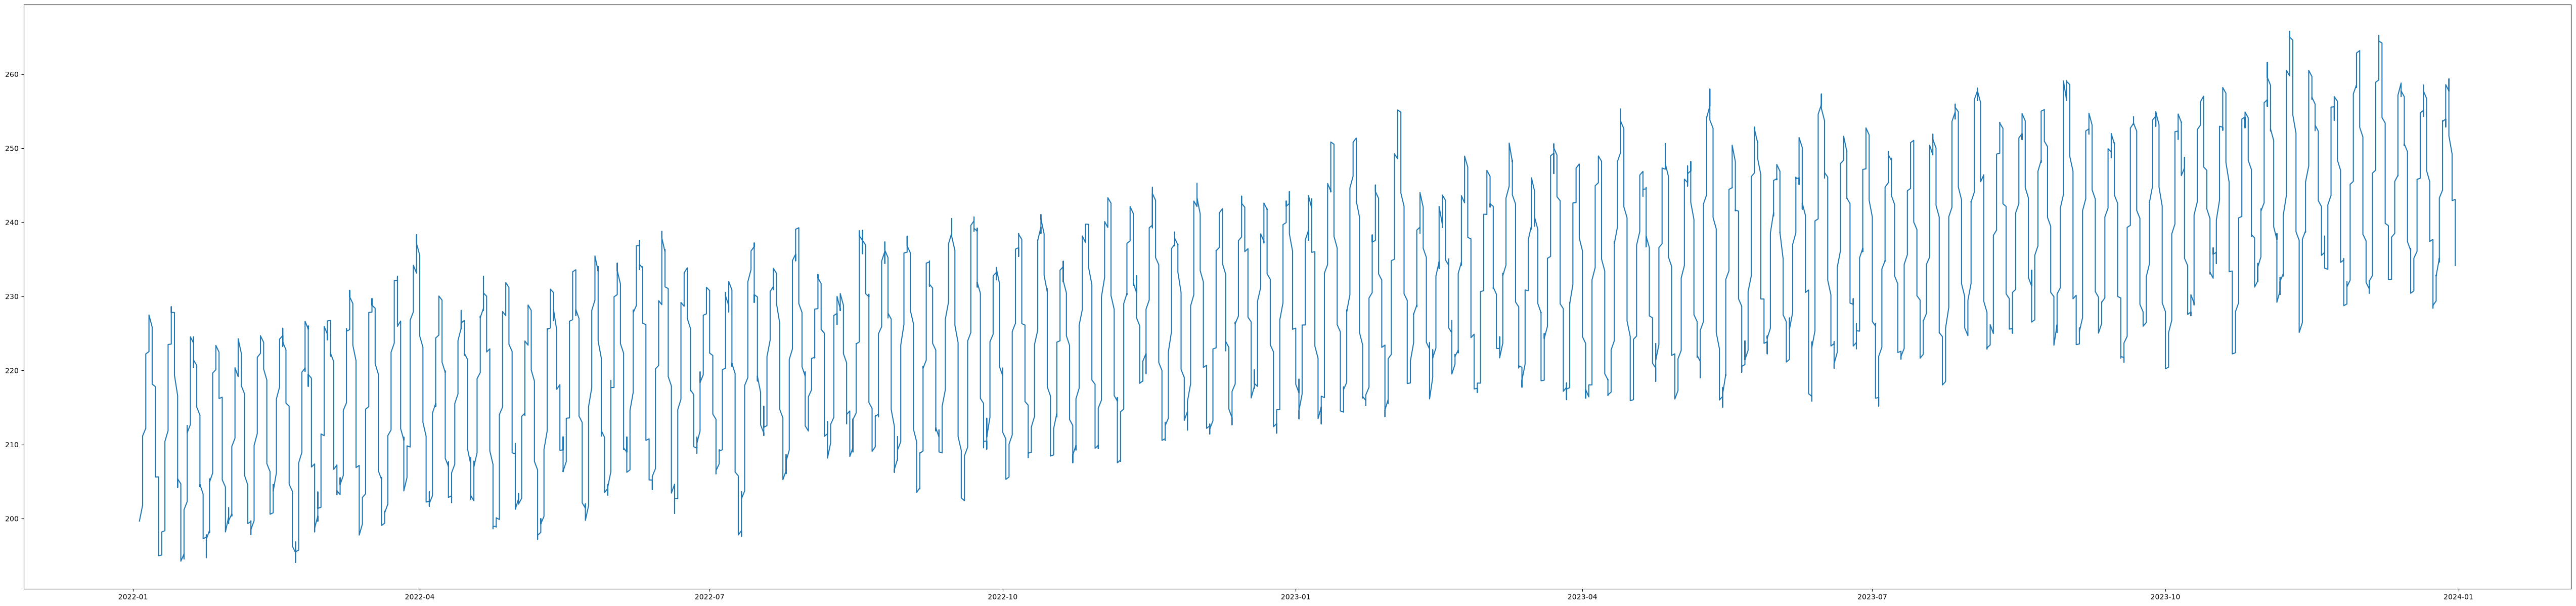

In [44]:
#Rolling mean
plt.figure(figsize=(65,15))

plt.plot(df['sales'].rolling(30).mean())
plt.show()

<Axes: xlabel='date_time', ylabel='sales'>

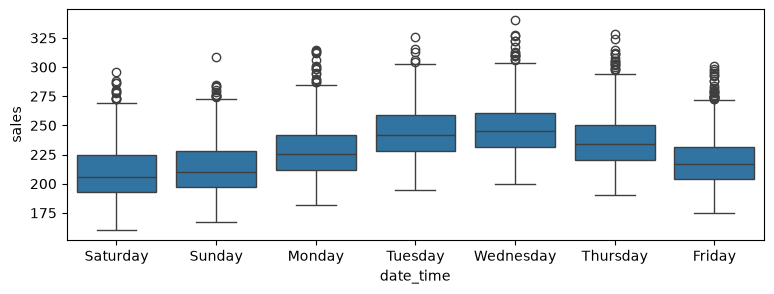

In [60]:
#Weekly Seasonality
plt.figure(figsize=(9,3))
sns.boxplot(y=df['sales'] , x=df.index.day_name())



<Axes: xlabel='date_time', ylabel='sales'>

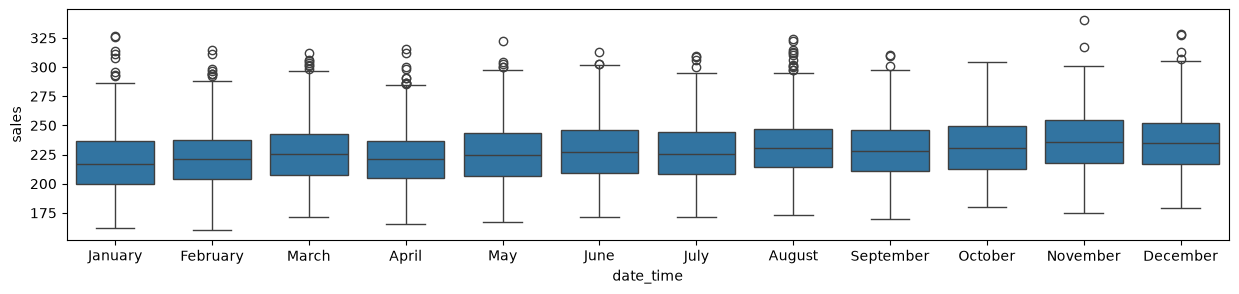

In [64]:
#Monthly Seasonality
plt.figure(figsize=(15,3))
sns.boxplot(y=df['sales'] , x=df.index.month_name())

<Axes: xlabel='date_time', ylabel='sales'>

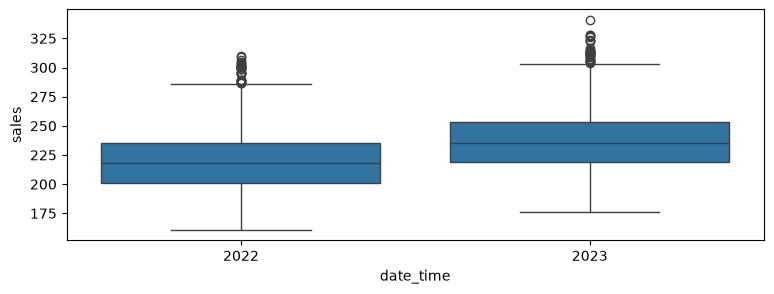

In [ ]:
#yearly Seasonality
plt.figure(figsize=(9,3))
sns.boxplot(y=df['sales'] , x=df.index.year)

<Axes: xlabel='holiday', ylabel='sales'>

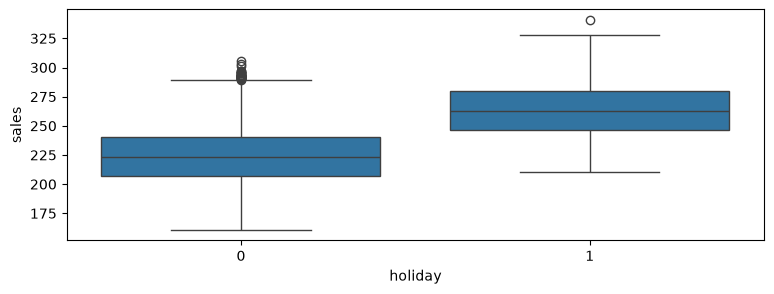

In [66]:
#holiday effect
plt.figure(figsize=(9,3))
sns.boxplot(y=df['sales'] , x=df['holiday'])

<Axes: xlabel='promo', ylabel='sales'>

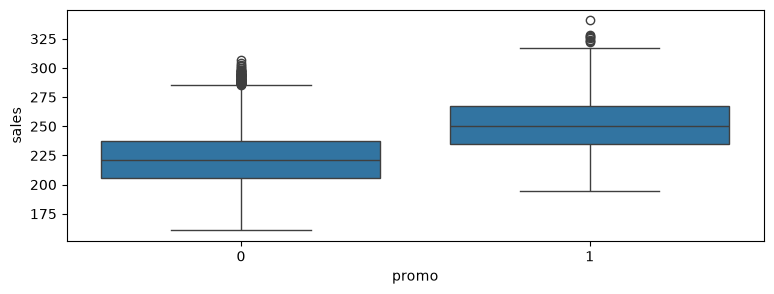

In [67]:
# Promotion effect
plt.figure(figsize=(9,3))
sns.boxplot(y=df['sales'] , x=df['promo'])

#checklist before STL
1.Index is DatetimeIndex?	df.index = pd.to_datetime(df.index)
2.Frequency set?	df = df.asfreq('D')
3.No missing values?	df['sales'] = df['sales'].interpolate()
4.Seasonal period known?	Use autocorrelation plot or domain knowledge

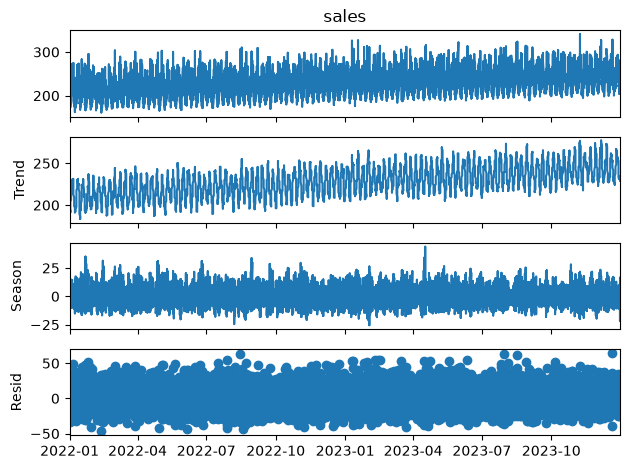

In [78]:
#Applying seasonal Decomposition

from statsmodels.tsa.seasonal import STL
stl=STL(df['sales'] , period=7)
result=stl.fit()
result.plot()
plt.show()

In [93]:
#exploring residual

residual = result.resid

residual_mean = residual.mean()
residual_std = residual.std()

print("Mean of Residual:" , residual_mean)
print("Standard Deviation of Residual:" , residual_std)

Mean of Residual: -0.0014648085638454798
Standard Deviation of Residual: 15.386864526661057


In [98]:
#Anomalities using Z score
threshold = 3 #assumption 99.73% CI
anomaly_scores = np.abs((residual - residual_mean) / residual_std)

#Flag anomalies
df['anomaly'] = anomaly_scores > threshold
df['anomaly_score'] = anomaly_scores

df.head()

,date,store,sales,promo,holiday,anomaly,anomaly_score
date_time,,,,,,,
2022-01-01,2022-01-01,1,184.78,0,0,False,1.808056
2022-01-01,2022-01-01,2,167.91,0,0,False,0.908820
2022-01-01,2022-01-01,3,217.27,0,1,False,1.410580
2022-01-01,2022-01-01,4,177.10,0,0,False,0.502079
2022-01-01,2022-01-01,5,171.59,0,0,False,0.157762


In [99]:
df[df['anomaly']==True].head()

,date,store,sales,promo,holiday,anomaly,anomaly_score
date_time,,,,,,,
2022-01-06,2022-01-06,8,274.78,1,1,True,3.146351
2022-01-21,2022-01-21,4,273.13,1,1,True,3.064849
2022-01-26,2022-01-26,9,295.46,1,1,True,3.329258
2022-02-12,2022-02-12,10,160.71,0,0,True,3.053759
2022-03-02,2022-03-02,4,303.56,1,1,True,3.031076


[7262   38]


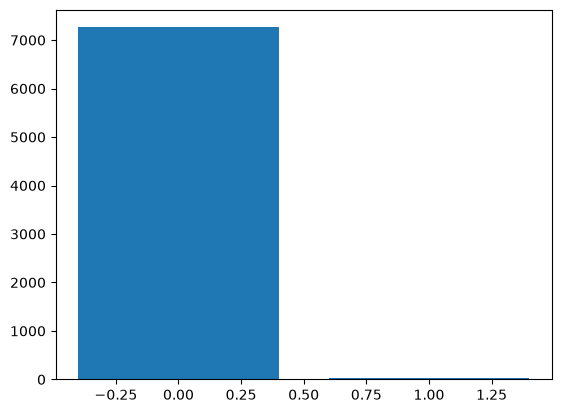

In [109]:
print(df['anomaly'].value_counts().values)

a=df['anomaly'].value_counts().index
b=df['anomaly'].value_counts().values
plt.bar(a,b)
plt.show()



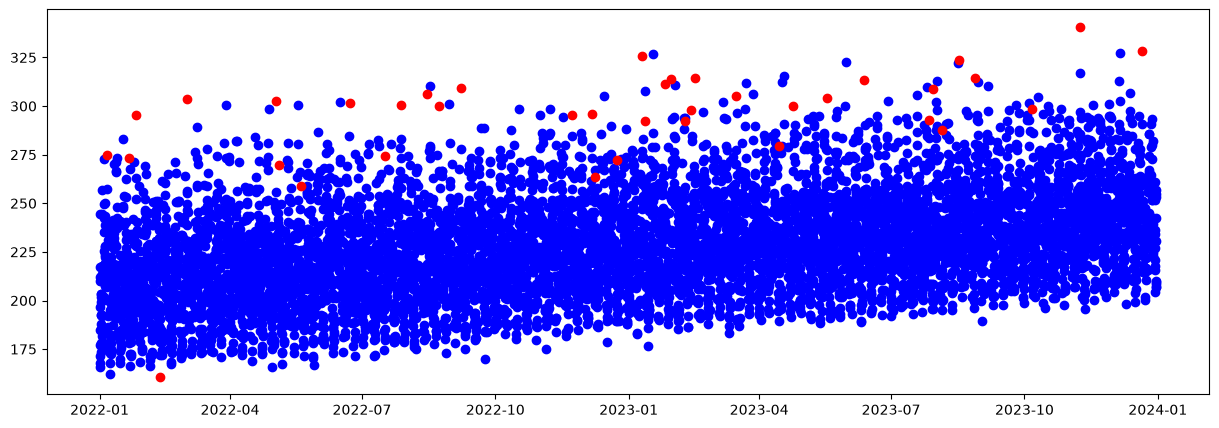

In [124]:
#anlomilities plot

df_normal=df[df['anomaly']==False] 
df_anomaly=df[df['anomaly']==True] 

plt.figure(figsize=(15,5))
plt.scatter(df_normal.index, df_normal['sales'], c='blue')
plt.scatter(df_anomaly.index, df_anomaly['sales'], c='red')
plt.show()


## ***2: DATA Cleaning***